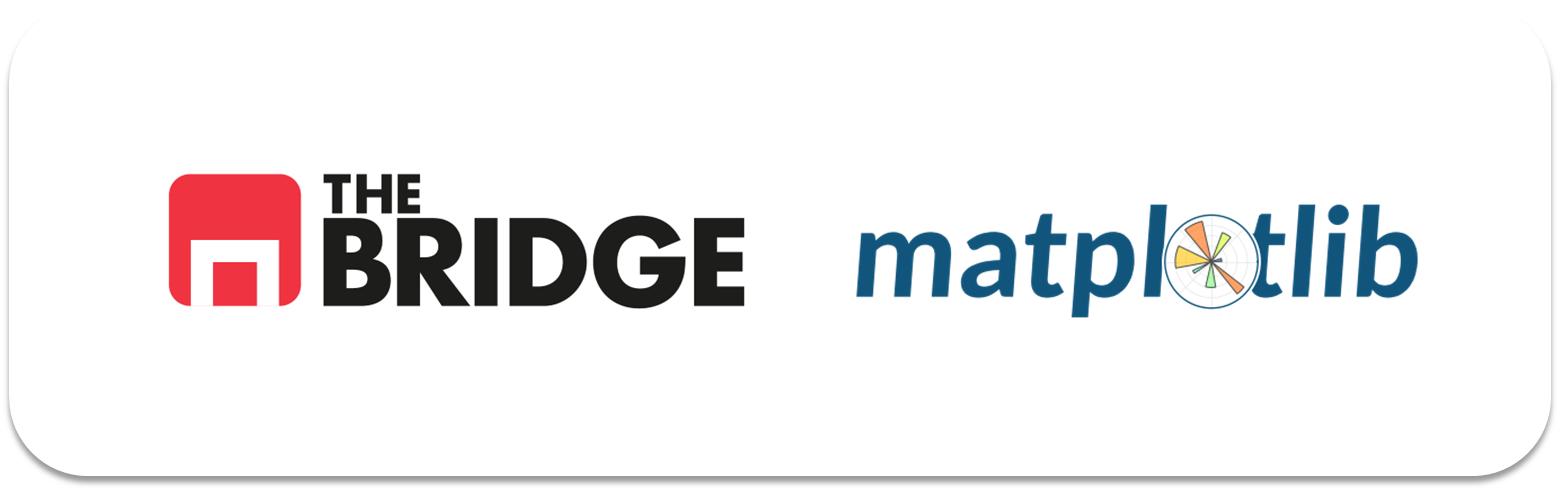

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configuración para que las gráficas se vean mejor
plt.style.use('default')
%matplotlib inline

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [8]:
df= pd.read_csv("./data/california_cities.csv")

# Mostramos las primeras filas para entender la estructura
print("Primeras filas del dataset:")
print(df.head())
print("\nInformación del dataset:")
print(df.info())
print("\nEstadísticas descriptivas:")
print(df.describe())


# IMPORTANTE: Eliminamos las filas con valores nulos
filas_originales = len(df)
df = df.dropna()


Primeras filas del dataset:
   Unnamed: 0         city       latd       longd  elevation_m  elevation_ft  \
0           0     Adelanto  34.576111 -117.432778        875.0        2871.0   
1           1  AgouraHills  34.153333 -118.761667        281.0         922.0   
2           2      Alameda  37.756111 -122.274444          NaN          33.0   
3           3       Albany  37.886944 -122.297778          NaN          43.0   
4           4     Alhambra  34.081944 -118.135000        150.0         492.0   

   population_total  area_total_sq_mi  area_land_sq_mi  area_water_sq_mi  \
0             31765            56.027           56.009             0.018   
1             20330             7.822            7.793             0.029   
2             75467            22.960           10.611            12.349   
3             18969             5.465            1.788             3.677   
4             83089             7.632            7.631             0.001   

   area_total_km2  area_land_km2  

#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center"). (Colores: azul, gris, aceituna, marrón, con trasparencia)  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Bradley Hand ITC", tamaño 18, color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion.
4. El boxplot de la altura de las ciudades.

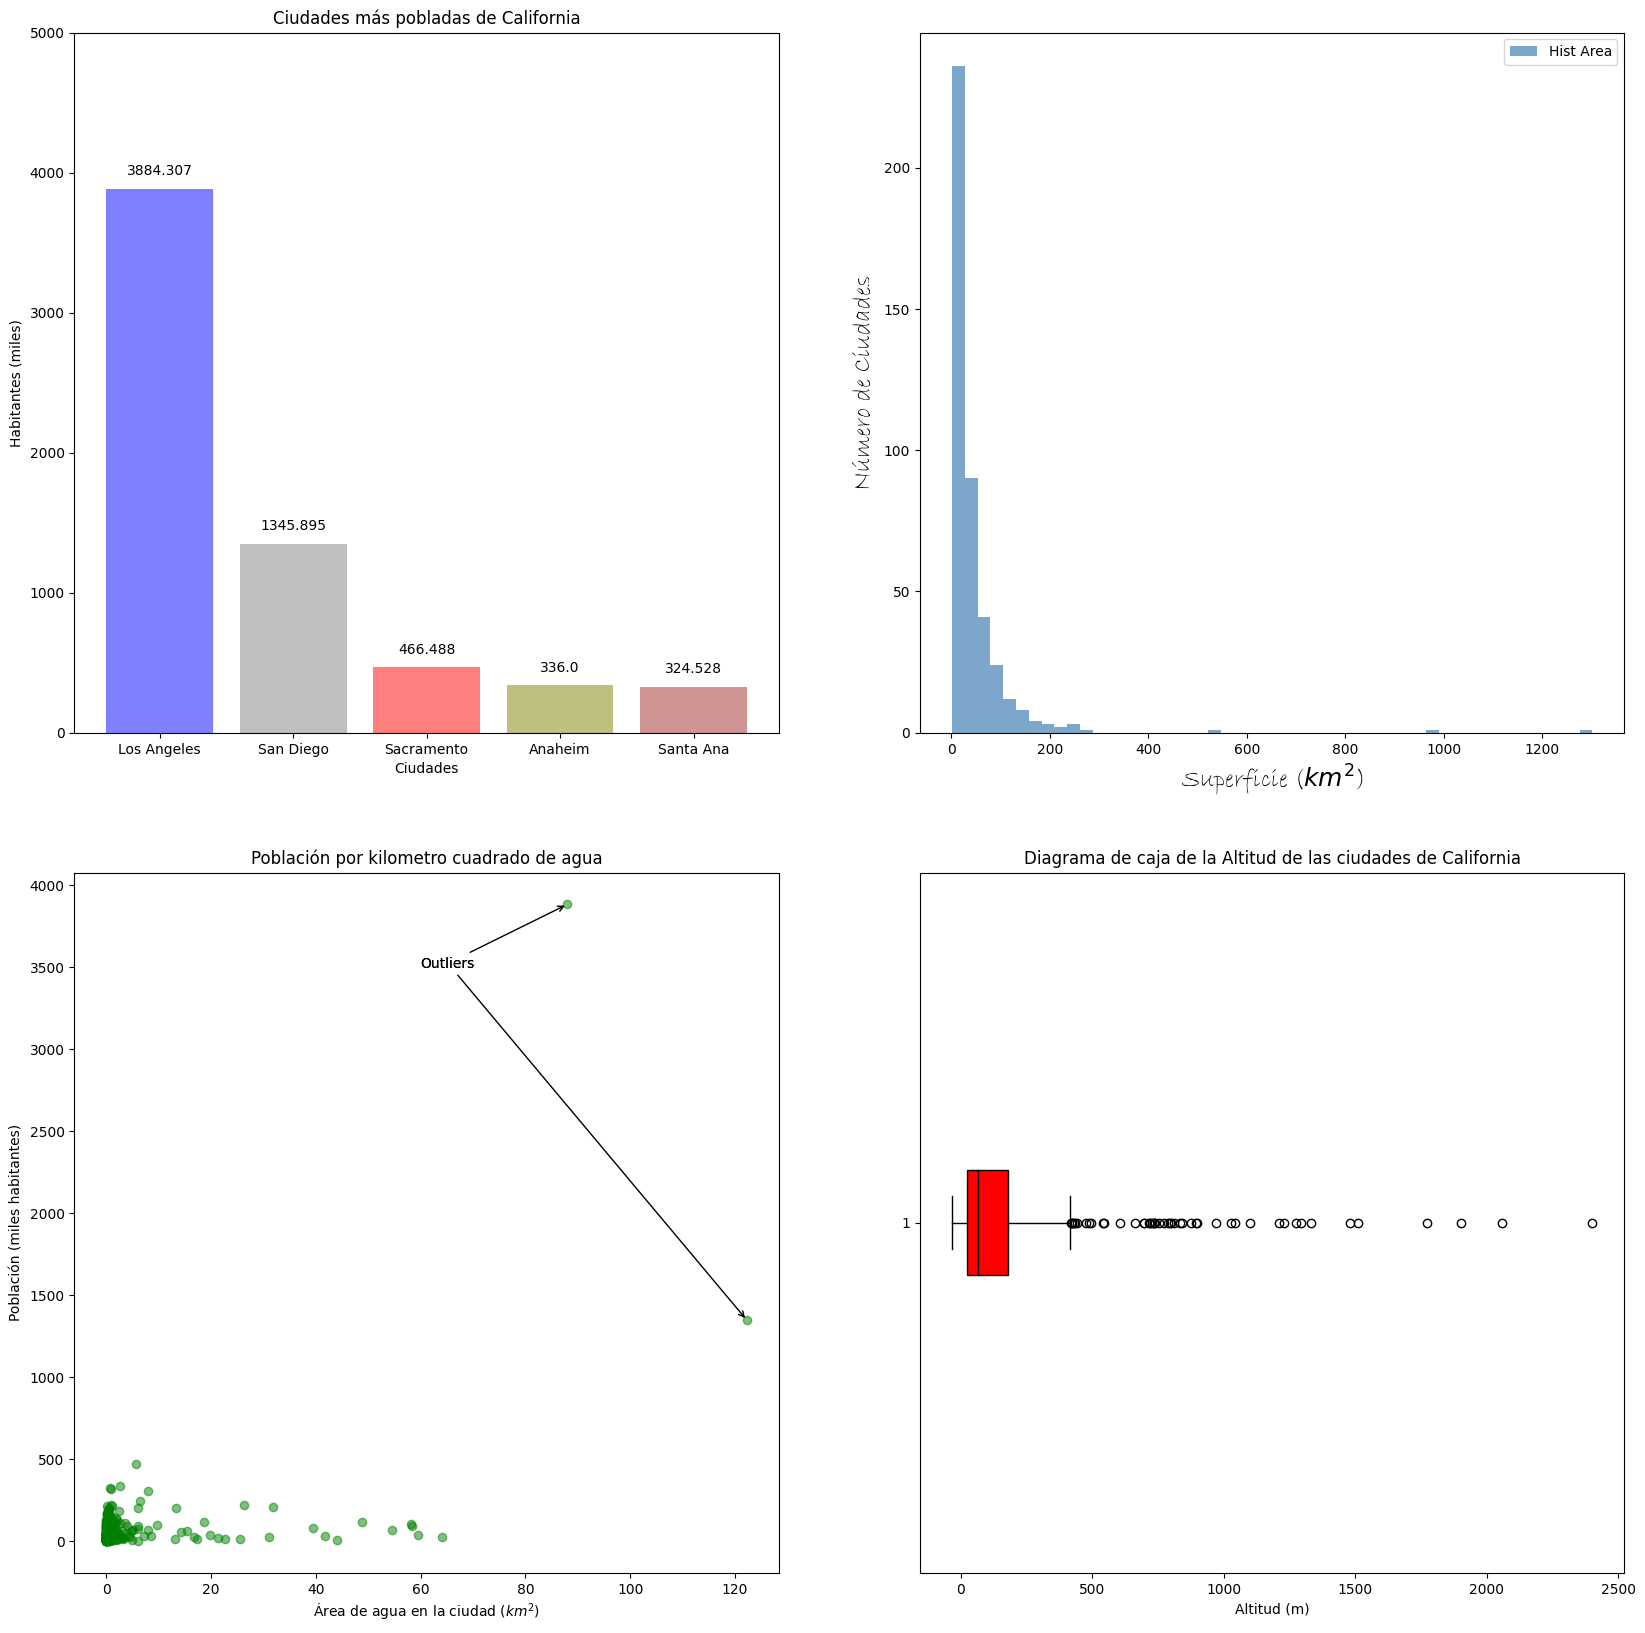

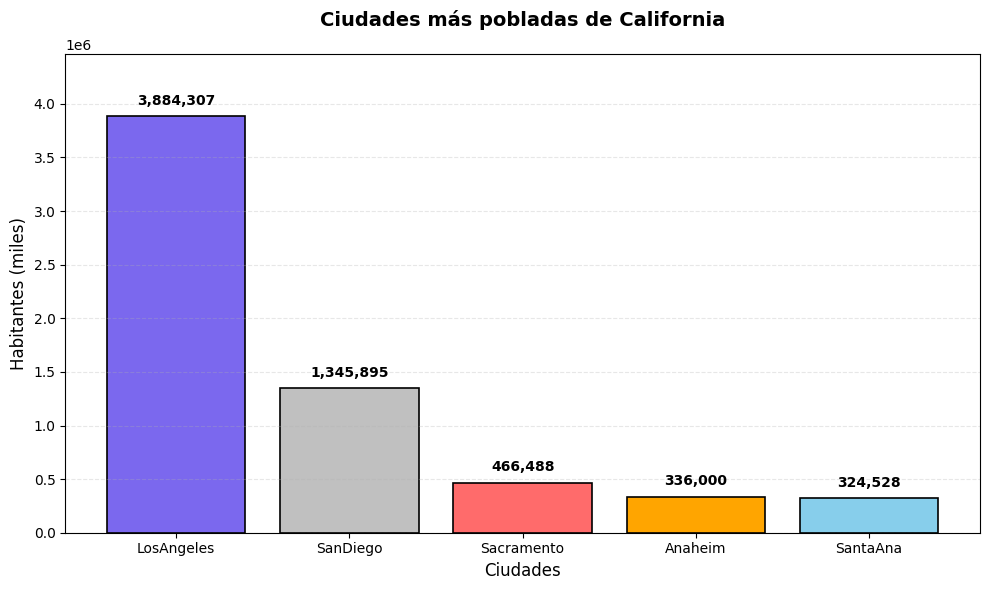

In [ ]:
# Grafico de barras
# Seleccionamos las 5 ciudades más pobladas
top5_ciudades = df.nlargest(5, 'population_total').copy()

plt.figure(figsize=(10, 6))

# Definimos colores para cada barra (como en la imagen de referencia)
colores = ['#7B68EE', '#C0C0C0', "#FF6B6B", '#FFA500', '#87CEEB']

# Creamos las barras
barras = plt.bar(top5_ciudades['city'], top5_ciudades['population_total'], 
                 color=colores, edgecolor='black', linewidth=1.2)

# Añadimos las etiquetas con los valores encima de cada barra
for i, (ciudad, valor) in enumerate(zip(top5_ciudades['city'], top5_ciudades['population_total'])):
    # Ajustamos la posición según el valor máximo
    offset = max(top5_ciudades['population_total']) * 0.02
    plt.text(i, valor + offset, f'{int(valor):,}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Configuramos título y etiquetas
plt.title('Ciudades más pobladas de California', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Ciudades', fontsize=12)
plt.ylabel('Habitantes (miles)', fontsize=12)

# Ajustamos los límites del eje y para que se vean bien las etiquetas
plt.ylim(0, max(top5_ciudades['population_total']) * 1.15)

# Añadimos una cuadrícula sutil en el eje y
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Ajustamos el diseño
plt.tight_layout()
plt.show()

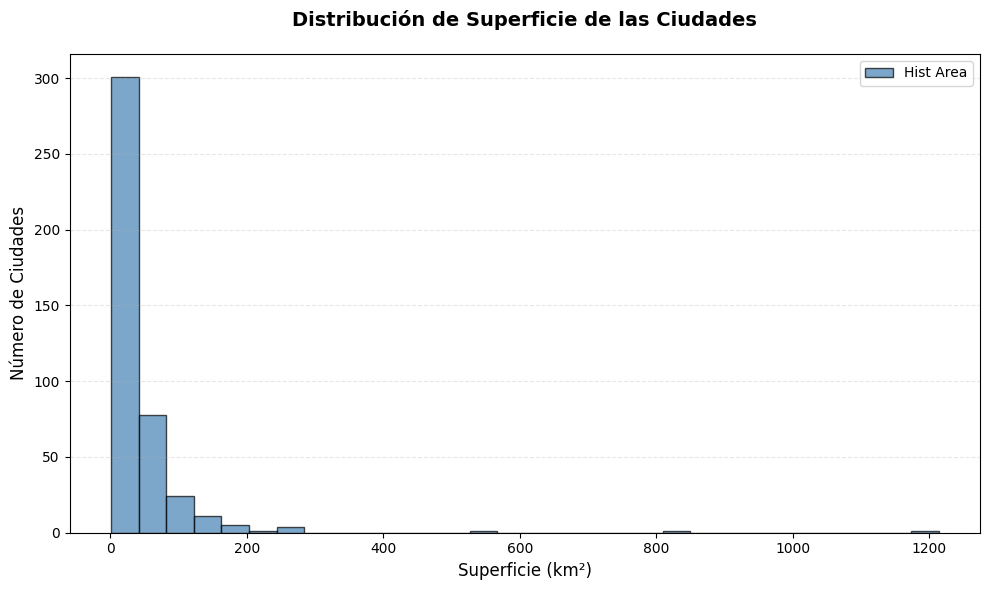

Total de ciudades: 427
Superficie promedio: 42.20 km²
Superficie máxima: 1214.00 km²


In [11]:
# Ejercicio 2: Histograma
plt.figure(figsize=(10, 6))

# Usamos la columna de área de tierra (land area)
# Eliminamos valores nulos si los hay
superficie_data = df['area_land_km2'].dropna()

# Creamos el histograma con aproximadamente 30 bins
n, bins, patches = plt.hist(superficie_data, bins=30, 
                            color='steelblue', edgecolor='black', 
                            alpha=0.7, label='Hist Area')

# Configuramos título y etiquetas
plt.title('Distribución de Superficie de las Ciudades', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Superficie (km²)', fontsize=12)
plt.ylabel('Número de Ciudades', fontsize=12)

# Añadimos leyenda
plt.legend(loc='upper right', fontsize=10)

# Añadimos cuadrícula
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print(f"Total de ciudades: {len(superficie_data)}")
print(f"Superficie promedio: {superficie_data.mean():.2f} km²")
print(f"Superficie máxima: {superficie_data.max():.2f} km²")

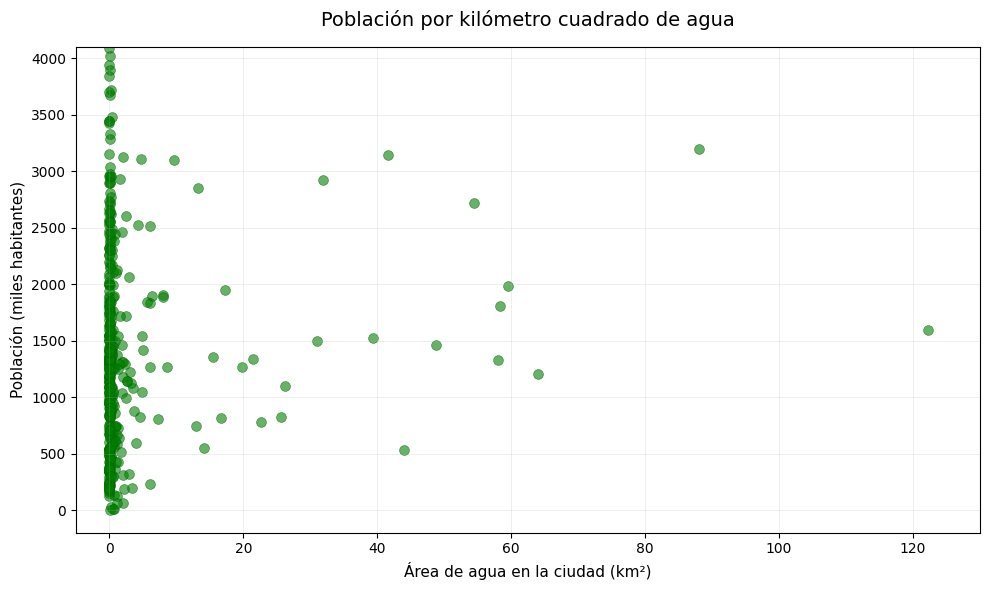

In [ ]:
# Scatter plot
plt.figure(figsize=(10, 6))

# Primero calculamos la densidad de población si no existe
if 'population_density' not in df.columns:
    df['population_density'] = df['population_total'] / df['area_land_km2']

# Preparamos los datos para el scatter
df_clean = df[['area_water_km2', 'population_density']].copy()

# Creamos el scatter plot
plt.scatter(df_clean['area_water_km2'], df_clean['population_density'], 
           c='green', alpha=0.6, s=50, edgecolors='darkgreen', linewidths=0.5)

# Identificamos outliers más específicamente
# Los outliers reales están muy por encima del resto (>1000 en densidad)
outliers = df_clean[df_clean['population_density'] > 1000]

# Anotamos los outliers principales
if len(outliers) > 0:
    # Obtenemos los outliers más extremos
    top_outliers = outliers.nlargest(min(3, len(outliers)), 'population_density')
    
    # Anotamos solo el punto más extremo para no saturar
    if len(top_outliers) > 0:
        # Encontramos el punto más extremo
        max_outlier = top_outliers.iloc[0]
        
        plt.annotate('Outliers', 
                    xy=(max_outlier['area_water_km2'], max_outlier['population_density']),
                    xytext=(60, 3500),  # Posición fija para la etiqueta
                    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                    fontsize=11, fontweight='normal')

# Configuramos título y etiquetas
plt.title('Población por kilómetro cuadrado de agua', fontsize=14, fontweight='normal', pad=15)
plt.xlabel('Área de agua en la ciudad (km²)', fontsize=11)
plt.ylabel('Población (miles habitantes)', fontsize=11)

# Ajustamos los límites para que se vea como en la imagen
plt.xlim(-5, 130)
plt.ylim(-200, 4100)

# Añadimos cuadrícula sutil
plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Configuramos los ticks
plt.xticks([0, 20, 40, 60, 80, 100, 120])
plt.yticks([0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000])

plt.tight_layout()
plt.show()


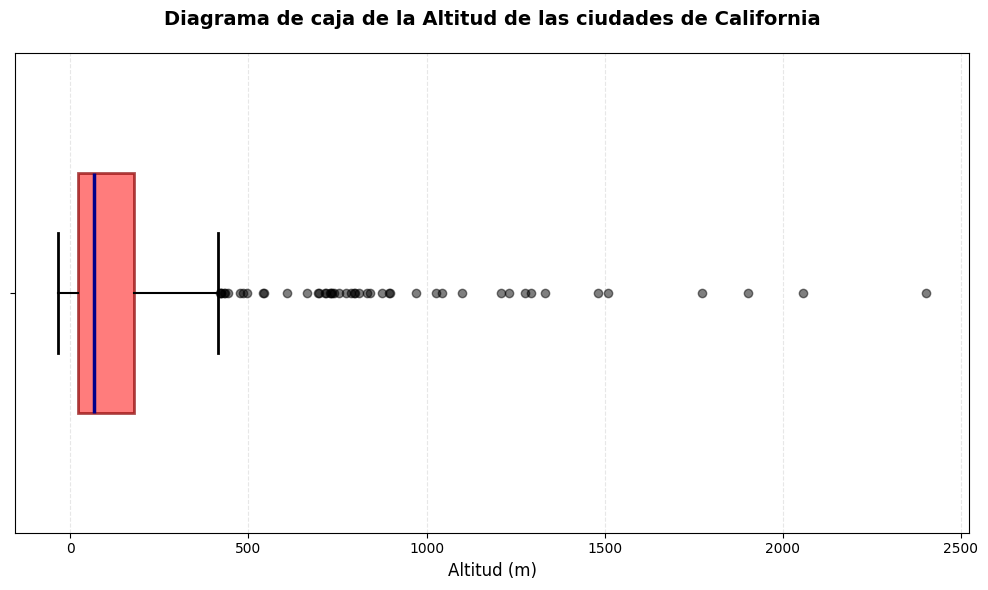

In [16]:
# Box plot
plt.figure(figsize=(10, 6))

# Preparamos los datos de altitud (eliminamos valores nulos)
altitudes = df['elevation_m'].dropna()

# Creamos el boxplot horizontal
box = plt.boxplot([altitudes], 
                   vert=False,  # Horizontal
                   patch_artist=True,  # Para poder colorear
                   widths=0.5,
                   showfliers=True,  # Mostrar outliers
                   flierprops=dict(marker='o', markerfacecolor='black', 
                                  markersize=6, linestyle='none', alpha=0.5))

# Personalizamos los colores (caja roja como en la imagen)
for patch in box['boxes']:
    patch.set_facecolor('#FF4444')
    patch.set_alpha(0.7)
    patch.set_edgecolor('darkred')
    patch.set_linewidth(2)

for whisker in box['whiskers']:
    whisker.set(color='black', linewidth=1.5)

for cap in box['caps']:
    cap.set(color='black', linewidth=2)

for median in box['medians']:
    median.set(color='darkblue', linewidth=2.5)

# Configuramos título y etiquetas
plt.title('Diagrama de caja de la Altitud de las ciudades de California', 
         fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Altitud (m)', fontsize=12)

# Quitamos las etiquetas del eje y
plt.yticks([1], [''])

# Añadimos cuadrícula vertical
plt.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

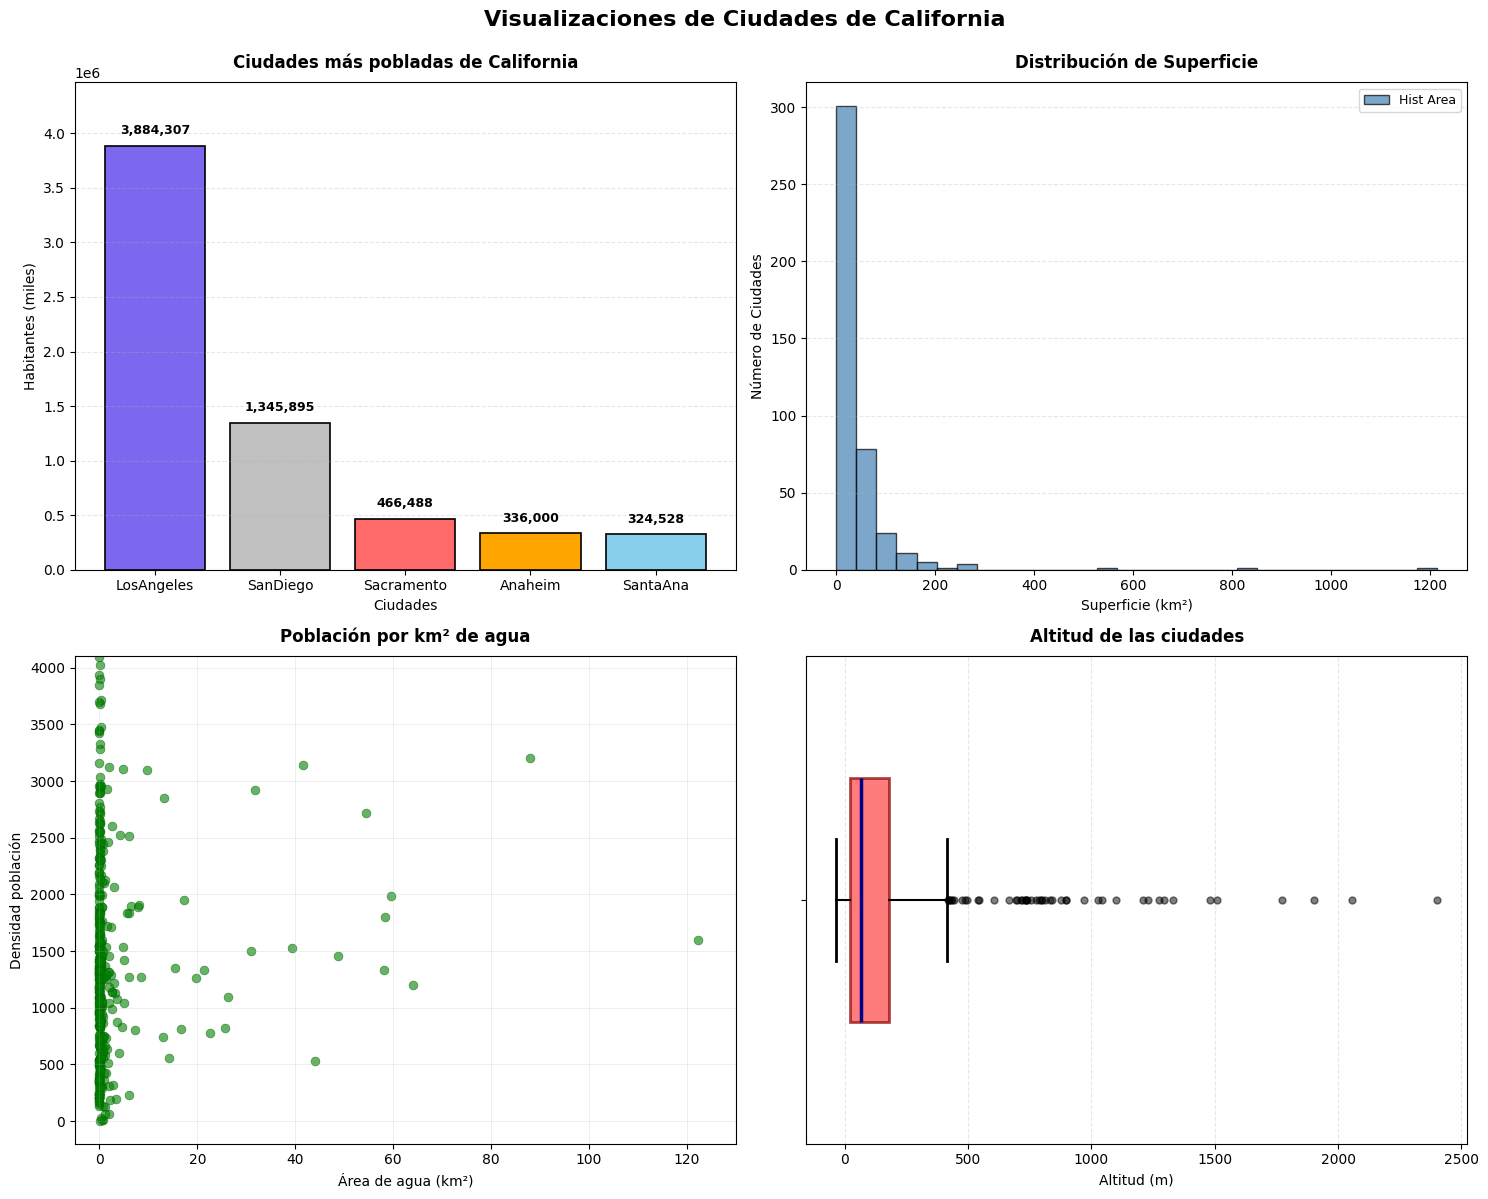

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Visualizaciones de Ciudades de California', fontsize=16, fontweight='bold', y=0.995)

if 'population_density' not in df.columns:
    df['population_density'] = df['population_total'] / df['area_land_km2']

# SUBPLOT 1: Barras
ax1 = axes[0, 0]
top5 = df.nlargest(5, 'population_total')
colores = ['#7B68EE', '#C0C0C0', '#FF6B6B', '#FFA500', '#87CEEB']
bars = ax1.bar(top5['city'], top5['population_total'], color=colores, edgecolor='black', linewidth=1.2)
for i, (ciudad, valor) in enumerate(zip(top5['city'], top5['population_total'])):
    ax1.text(i, valor + max(top5['population_total']) * 0.02, f'{int(valor):,}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_title('Ciudades más pobladas de California', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Ciudades', fontsize=10)
ax1.set_ylabel('Habitantes (miles)', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim(0, max(top5['population_total']) * 1.15)

# SUBPLOT 2: Histograma
ax2 = axes[0, 1]
superficie_data = df['area_land_km2']
ax2.hist(superficie_data, bins=30, color='steelblue', edgecolor='black', alpha=0.7, label='Hist Area')
ax2.set_title('Distribución de Superficie', fontsize=12, fontweight='bold', pad=10)
ax2.set_xlabel('Superficie (km²)', fontsize=10)
ax2.set_ylabel('Número de Ciudades', fontsize=10)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# SUBPLOT 3: Scatter
ax3 = axes[1, 0]
df_scatter = df[['area_water_km2', 'population_density']].copy()
ax3.scatter(df_scatter['area_water_km2'], df_scatter['population_density'], 
           c='green', alpha=0.6, s=40, edgecolors='darkgreen', linewidths=0.5)
outliers = df_scatter[df_scatter['population_density'] > 1000]
if len(outliers) > 0:
    max_outlier = outliers.nlargest(1, 'population_density').iloc[0]
    ax3.annotate('Outliers', 
                xy=(max_outlier['area_water_km2'], max_outlier['population_density']),
                xytext=(60, 3500),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
                fontsize=9, fontweight='normal')
ax3.set_title('Población por km² de agua', fontsize=12, fontweight='bold', pad=10)
ax3.set_xlabel('Área de agua (km²)', fontsize=10)
ax3.set_ylabel('Densidad población', fontsize=10)
ax3.set_xlim(-5, 130)
ax3.set_ylim(-200, 4100)
ax3.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# SUBPLOT 4: Box Plot
ax4 = axes[1, 1]
altitudes = df['elevation_m']
box = ax4.boxplot([altitudes], vert=False, patch_artist=True, widths=0.5,
                   showfliers=True,
                   flierprops=dict(marker='o', markerfacecolor='black', markersize=5, linestyle='none', alpha=0.5))
for patch in box['boxes']:
    patch.set_facecolor('#FF4444')
    patch.set_alpha(0.7)
    patch.set_edgecolor('darkred')
    patch.set_linewidth(2)
for whisker in box['whiskers']:
    whisker.set(color='black', linewidth=1.5)
for cap in box['caps']:
    cap.set(color='black', linewidth=2)
for median in box['medians']:
    median.set(color='darkblue', linewidth=2.5)
ax4.set_title('Altitud de las ciudades', fontsize=12, fontweight='bold', pad=10)
ax4.set_xlabel('Altitud (m)', fontsize=10)
ax4.set_yticks([1], [''])
ax4.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()

# GUARDAR LA FIGURA
ruta = r"C:\Users\priet\OneDrive\Documentos\Bootcamp_Data_Science\Git_Hub\repo_ejercicios_ds_ana\03_Data_Analysis\Sprint_08\Unidad_01_Visualizacion_Basica_Matplotlib\03_Practica_Obligatoria\grafico_5_visualizacion_completa.png"
plt.savefig(ruta, dpi=300, bbox_inches='tight')


plt.show()
